# CSCI443 Lecture 11 Notes

In this lecture we cover finish confidence intervals and move on to significance.


## Computing Confidence Intervals

A confidence interval is a range of values computed from sample
data to estimate a population parameter, such as the mean. Often
people incorrectly interpret a p% confidence interval as meaning
there is a p% probability that the interval contains the true
population parameter.

Confidence intervals answer a different question than most people
expect. They do not tell us how likely this particular interval is
to contain the true value. Instead, they tell us how well the method
performs over repeated samples.

We can compute a confidence interval for any statistic.  A *statistic* is an estimate of a 
distribution parameter.  So far we have used the sample mean as a statistic that estimates
the distribution mean.  I will continue to use the sample mean as an estimate of the
distribution mean for purposes of illustration, but keep mind that the sample standard
deviation is also a statistic, but it estimates the distribution standard deviation, and 
analogously for statistcs that estimate other distribution parameters.

1. We compute the sample mean $\bar{x}$.
2. We note how big is $n$.  If $n > 30$ we may use a Gaussian approximation for the sampling distribution of the sample mean.  (We will come back to handle the case when $n < 30$).
3. Compute the sample standard deviation $s_x$ and use this as an estimate of $\sigma$.
4. Compute the standard error based on $s_x$.

$$SE_s = \frac{s_x}{\sqrt{n}}$$

5. For a given confidence level $p$.  Sometimes we  use the term *significance level* $\alpha$ where $\alpha=1-p$, compute the critical Z-score for the given confidence level.

$$Z_{\alpha} = \Phi^{-1}(1-\alpha/2)$$

or 

$$Z_p = \Phi^{-1}\bigg(1-\frac{1-p}{2}\bigg)$$

6. Compute upper and lower bounds of the confidence interval.

$$CI_{lo} = \bar{x} - Z_p \cdot SE_s$$

$$CI_{hi} = \bar{x} + Z_p \cdot SE_s$$

In Step 5, I use the function $\Phi^{-1}(p)$.  This is the inverse of the Gaussian
CDF.  I illustrate $\Phi^{-1}(p)$ below and include annotations for the case when 
$P[X \leq x] = 90%$.  But where does the $1-\frac{1-p}{2}$ come from?

A:

$$P[-x \leq X \leq x] = \Phi(x)-\Phi(-x)$$

This can be rewritten as 1 - upper tail - lower tail.
The probability of a sample landing in the upper tail is given by 

$$P[\text{landing in upper tail}] = 1-P[x \leq X] = 1- \Phi(x)$$

Since the distribution is symmetric, both tails are equal, and thus 

$$P[\text{landing in either tail}] = 2 \cdot ( 1 - \Phi(x))$$

The probability that $X \in [-x, x]$ is $1-P[\text{landing in either tail}]$ so

$$P[-x \leq X \leq x] = 1 - 2(1 - \Phi(x)) = p$$

Rearranging yields

$$1-p = 2(1-\Phi(x))$$

$$\frac{1-p}{2} = 1-\Phi(x)$$

$$\Phi(x) = 1-\frac{1-p}{2}$$

$$\Phi^{-1}(\Phi(x)) = \Phi^{-1}\bigg(1-\frac{1-p}{2}\bigg)$$

$$Z_p = x = \Phi^{-1}\bigg(1-\frac{1-p}{2}\bigg)$$  

Simplifying yields

$$\boxed{Z_p = \Phi^{-1}\bigg(\frac{1+p}{2}\bigg)}$$


In [5]:
import pandas as pd
import numpy as np
from scipy import stats
from IPython.display import display, HTML


#x_values = np.append(np.array([0, 0.5]), np.linspace(1, 3, 9))  # 16 values from 0 to 3
x_values = np.append(np.linspace(0, 3, 7), [1.96])
x_values = np.sort(x_values)
phi_values = stats.norm.cdf(x_values)  # Compute the Gaussian CDF

# Create a DataFrame for better visualization
df = pd.DataFrame({
    r"$Z_p$": x_values,
    r"$\Phi(Z_p)$": np.round(phi_values, decimals=4),
    r"$2\Phi(Z_p))-1$": np.round(1-2*(1-phi_values), decimals=4)
})

# Convert to HTML without index
html_table = df.to_html(index=False)

# Display the table
display(HTML(html_table))

$Z_p$,$\Phi(Z_p)$,$2\Phi(Z_p))-1$
0.00,0.5000,0.0000
0.50,0.6915,0.3829
1.00,0.8413,0.6827
1.50,0.9332,0.8664
1.96,0.9750,0.9500
2.00,0.9772,0.9545
2.50,0.9938,0.9876
3.00,0.9987,0.9973


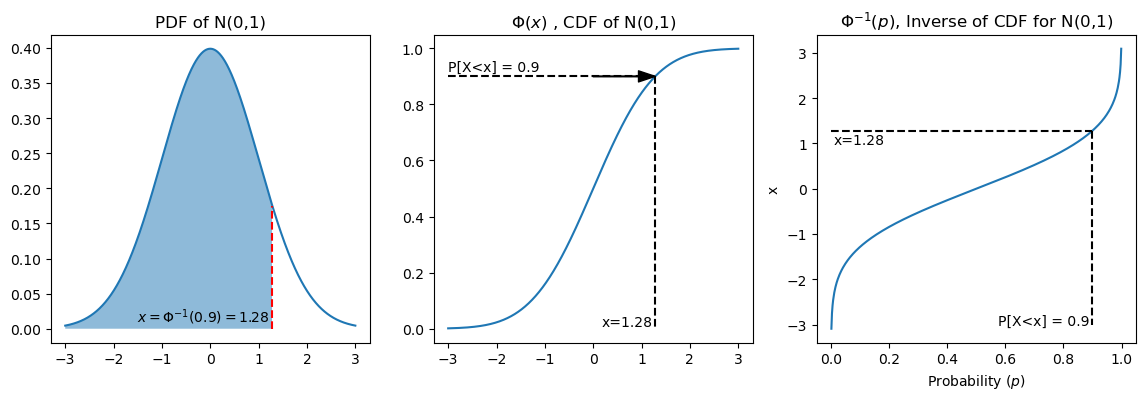

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Define the points for the plots
x_points = np.linspace(-3, 3, 1000)
pdf_points = norm.pdf(x_points)
cdf_points = norm.cdf(x_points)

p_points = np.linspace(0.001, 0.999, 500)
ppf_points = norm.ppf(p_points)

# Calculate the x value for the 90th percentile
x_90th = norm.ppf(0.9)

# Create subplots
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

# Plot PDF with the area under the curve filled for the bottom 90%
ax[0].plot(x_points, pdf_points, label='PDF of N(0,1)')
ax[0].fill_between(x_points, pdf_points, where=(x_points <= x_90th), alpha=0.5)
ax[0].vlines(x_90th, 0, norm.pdf(x_90th), colors='r', linestyles='dashed', label=f'x = $\\Phi^{{-1}}$(0.9) = {x_90th:.2f}')
ax[0].text(x_90th-0.05, 0.01, f'$x=\\Phi^{{-1}}(0.9)={x_90th:.2f}$', ha='right')
#ax[0].legend()
ax[0].set_title('PDF of N(0,1)')

# Plot CDF with arrow annotations
ax[1].plot(x_points, cdf_points, label='CDF of N(0,1)')
ax[1].annotate('', xy=(x_90th, 0.9), xytext=(0, 0.9),
               arrowprops=dict(facecolor='black', shrink=0, width=0.5, headwidth=8))
ax[1].annotate('', xy=(x_90th, 0), xytext=(x_90th, 0),
               arrowprops=dict(facecolor='black', shrink=0, width=0.5, headwidth=8))
ax[1].vlines(x_90th, 0.9, 0, colors='black', linestyles='dashed')
ax[1].hlines(0.9, -3, x_90th, colors='black', linestyles='dashed')
ax[1].text(-3, 0.91, r'P[X<x] = 0.9', va='bottom')
ax[1].text(x_90th-0.05, 0.01, f'x={x_90th:.2f}', ha='right')
ax[1].set_title(r'$\Phi(x)$ , CDF of N(0,1)')

ax[2].plot(p_points, ppf_points)
ax[2].vlines(0.9, x_90th, -3, colors='black', linestyles='dashed')
ax[2].hlines(x_90th, 0, 0.9, colors='black', linestyles='dashed')
ax[2].text(0.89, -3, r'P[X<x] = 0.9', ha='right')
ax[2].text(0.01, x_90th-0.05, f'x={x_90th:.2f}', va='top')
ax[2].set_title(r'$\Phi^{-1}(p)$, Inverse of CDF for N(0,1)')
ax[2].set_xlabel(r'Probability ($p$)')
ax[2].set_ylabel('x')

plt.show()


In [55]:
import pandas as pd
import numpy as np
from scipy import stats
from IPython.display import display, HTML

# One-tailed probabilities
p_values = np.array([0.50, 0.68, 0.80, 0.90, 0.95, 0.975, 0.99, 0.995])

# One-tailed inverse CDF
phi_inv = stats.norm.ppf(p_values)

# Two-tailed central probabilities (interpret same p as central mass)
z_values = stats.norm.ppf((1 + p_values) / 2)

df = pd.DataFrame({
    "p": p_values,
    r"$\Phi^{-1}(p)$": np.round(phi_inv, 4),
    r"$Z_p = \Phi^{-1}\bigg(\frac{1+p}{2}\bigg)$": np.round(z_values, 4)
})

display(HTML(df.to_html(index=False)))

p,$\Phi^{-1}(p)$,$Z_p = \Phi^{-1}\bigg(\frac{1+p}{2}\bigg)$
0.500,0.0000,0.6745
0.680,0.4677,0.9945
0.800,0.8416,1.2816
0.900,1.2816,1.6449
0.950,1.6449,1.9600
0.975,1.9600,2.2414
0.990,2.3263,2.5758
0.995,2.5758,2.8070


In [28]:
import numpy as np
from math import sqrt

In [56]:

def compute_gaussian_confidence_interval(samples, confidence_level):
    """confidence_level is a number in (0,100)."""
    
    sample_mean = np.mean(samples)
    n = len(samples)
    sample_std = np.std(samples, ddof=1)
    print(sample_std)
    stderr = sample_std / sqrt(n)
    print(stderr)
    p = confidence_level / 100
    z_p = norm.ppf((1+p)/2)

    lower_bound = sample_mean - z_p * stderr
    upper_bound = sample_mean + z_p * stderr

    return sample_mean, lower_bound, upper_bound
    
    

## Example 1 computing a confidence interval from samples

With 3 samples

$S = { 2, 1, 9 }$

$\overline{x} = \frac{2 + 1 + 9}{3} = 4$

$s_x = \sqrt{\frac{1}{n-1} \bigg(\sum_{i=1}^{n} x_i^2 - n\cdot \overline{x^2}\bigg)} \approx 4.3589$

$\text{SE } = \frac{s_x}{\sqrt{n}} = \frac{4.3589}{\sqrt{3}} \approx 2.517$

$CI = \overline{x} \pm 1.96 \cdot \text{SE} \approx 4 \pm 1.96 \cdot 2.517 \approx \boxed{[-0.93, 8.93]}$

In [38]:
# confirm result in Example 1
compute_gaussian_confidence_interval([2,1,9], 95)

(4.0, -0.9324678607903234, 8.932467860790323)

## Example 2 computing a confidence interval from samples

With 3 samples

$S = { 0.04, 0.68, 1 }$

$\overline{x} = \frac{0.04+ 0.68 + 1}{3} \approx 0.573$

$s_x = \sqrt{\frac{1}{n-1} \bigg(\sum_{i=1}^{n} x_i^2 - n\cdot \overline{x^2}\bigg)} \approx 0.399$

$\text{SE } = \frac{s_x}{\sqrt{n}} = \frac{0.399}{\sqrt{3}} \approx 0.230$

$CI = \overline{x} \pm 1.96 \cdot \text{SE} \approx 0.573 \pm 1.96 \cdot 0.230 \approx \boxed{[0.12, 1.02]}$

In [43]:
# verify CI in Example 2
compute_gaussian_confidence_interval([0.04, 0.68, 1], 95)

0.4888080741286229
0.282213473180223


(0.5733333333333334, 0.020205089948135857, 1.1264615767185309)

In [ ]:
def compute_t_confidence_interval(samples, confidence_level):
    

In [58]:
import pandas as pd
import numpy as np
from scipy import stats
from IPython.display import display, HTML

# Sample sizes
n_values = np.arange(3, 31)   # n = 3, ..., 30
dof_values = n_values - 1     # dof = n - 1

# Build table
df = pd.DataFrame({
    "n": n_values,
    "dof": dof_values,
    "0.90": np.round(stats.t.ppf((1 + 0.90) / 2, df=dof_values), 4),
    "0.95": np.round(stats.t.ppf((1 + 0.95) / 2, df=dof_values), 4),
    "0.99": np.round(stats.t.ppf((1 + 0.99) / 2, df=dof_values), 4),
})

display(HTML(df.to_html(index=False)))

n,dof,0.90,0.95,0.99
3,2,2.9200,4.3027,9.9248
4,3,2.3534,3.1824,5.8409
5,4,2.1318,2.7764,4.6041
6,5,2.0150,2.5706,4.0321
7,6,1.9432,2.4469,3.7074
8,7,1.8946,2.3646,3.4995
9,8,1.8595,2.3060,3.3554
10,9,1.8331,2.2622,3.2498
11,10,1.8125,2.2281,3.1693
12,11,1.7959,2.2010,3.1058
